# Classification with Quantum Neural Networks
This tutorial gives an introduction to Quantum Neural Networks (QNNs) for classification.

A QNN is a parametrized quantum circuit that is trained like a classical neural network: classical data is encoded into a quantum state, a sequence of gates with tunable parameters processes this state, and a measurement produces the prediction. A classical optimizer then adjusts the parameters to minimize a loss function. In contrast to quantum reservoir computing, where the quantum system is fixed and only a classical readout is trained, the quantum circuit itself is the trainable model here.

The idea of using such circuits for supervised learning on near-term hardware was introduced by [Farhi & Neven](https://arxiv.org/abs/1802.06002). Closely related circuit-based classifiers were proposed by [Schuld et al.](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.101.032308).

As a benchmark we use the [Iris dataset](https://archive.ics.uci.edu/dataset/53/iris), introduced by Fisher in 1936: 150 iris flowers from three species, each described by four measurements. Four features fit onto four qubits, and the three species let us go beyond binary classification.

## Theoretical Overview

We consider a classification task with a training set $\{(\mathbf{x}_m, y_m)\}_{m=1}^M$, where $\mathbf{x}_m \in \mathbb{R}^d$ is a feature vector and $y_m \in \{0, \ldots, C-1\}$ its class. Our QNN on $n = d$ qubits consists of three parts:

1. **Encoding:** A circuit $S(\mathbf{x})$ loads the data into the state $\ket{\psi(\mathbf{x})} = S(\mathbf{x})\ket{0\ldots0}$. We use *angle encoding*: feature $x_i$, rescaled to $[0, \pi]$, rotates qubit $i$ by $R_Y(x_i)$.
2. **Parametrized circuit:** $L$ layers $U(\boldsymbol{\theta})$, each consisting of a trainable rotation $R_Y(\theta_{l,i})$ on every qubit followed by a ring of $CZ$ gates that entangles neighbouring qubits.
3. **Readout:** We measure a *readout register* $R$ of $r$ qubits. Its $2^r$ outcomes $c$ occur with probabilities $p_c(\mathbf{x}; \boldsymbol{\theta})$ and each class is assigned one outcome. For $C = 3$ classes we need $r = 2$ readout qubits. The prediction is the most likely *class* outcome, $\hat{y} = \operatorname{argmax}_{c < C}\, p_c(\mathbf{x}; \boldsymbol{\theta})$.

The parameters are trained by minimizing the cross-entropy loss

$$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{M}\sum_{m=0}^{M} \sum_{c=0}^{C} y_{m,c}\log (p_{m,c})$$
where $y_{m,c}=1$ if $c$ is the correct class of datapoint $m$ and $p_{m,c}$ is the predicted probability of $m$ being class $c$.

Increasing the probability of the correct class automatically decreases all other outcomes, including the unused one, so no extra treatment of $c = 3$ is necessary. Since every $p_c$ is the expectation value of a projector, its gradient can be evaluated on the quantum computer itself with the [parameter-shift rule](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.99.032331):

$$\frac{\partial p_c}{\partial \theta_j} = \frac{1}{2}\left[p_c\!\left(\boldsymbol{\theta} + \tfrac{\pi}{2}\mathbf{e}_j\right) - p_c\!\left(\boldsymbol{\theta} - \tfrac{\pi}{2}\mathbf{e}_j\right)\right], \qquad \frac{\partial \mathcal{L}}{\partial \theta_j} = -\frac{1}{M}\sum_m \frac{1}{p_{y_m}} \frac{\partial p_{y_m}}{\partial \theta_j}$$
where $\mathbf{e}_j$ is the $j$-th unit vector. We need this rule because on a quantum computer the probabilities are only accessible by running and measuring the circuit, so we cannot backpropagate through it as in a classical neural network. The parameter-shift rule instead gives the exact gradient from just two circuit evaluations per parameter, without the approximation error and amplified shot noise of finite differences.

A central challenge in training QNNs are [barren plateaus](https://www.nature.com/articles/s41467-018-07090-4): for deep, randomly initialized circuits the gradients vanish exponentially in the number of qubits. Shallow circuits on few qubits, like the one in this tutorial, avoid this problem.

### Preliminaries

Install scikit-learn, which provides the Iris dataset and the data preprocessing.

`pip install scikit-learn`

### Iris data

We split the 150 flowers into 105 training and 45 test samples, keeping the three species balanced in both parts. Each feature is then rescaled to $[0, \pi]$ so that it can be used directly as a rotation angle. The scaling is fitted on the training data only, and test values outside this range are clipped.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

iris = load_iris()
N_CLASSES = len(iris.target_names)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, stratify=iris.target, random_state=0)

# Rescale every feature to [0, pi] so that it can be used as a rotation angle
scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = np.clip(scaler.transform(X_test_raw), 0, np.pi)

print(f"Features: {iris.feature_names}")
print(f"Training data: {X_train.shape}, test data: {X_test.shape}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Training data: (105, 4), test data: (45, 4)


Let's look at the two petal measurements. *Setosa* is clearly separated from the other two species, while *versicolor* and *virginica* overlap slightly, so we can't expect a perfect classifier.

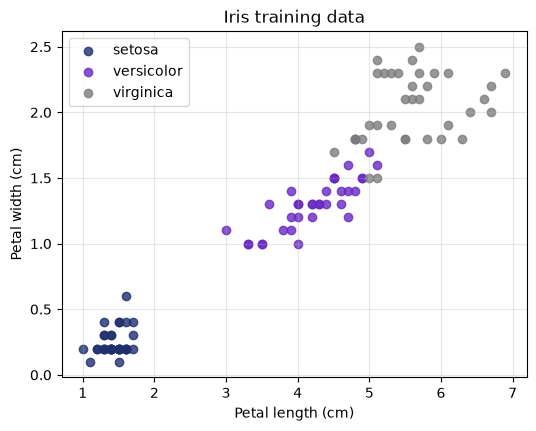

In [2]:
COLORS = ["#20306f", "#6929C4", "#7d7d7d"]

plt.figure(figsize=(6, 4.5))
for c, name in enumerate(iris.target_names):
    mask = y_train == c
    plt.scatter(X_train_raw[mask, 2], X_train_raw[mask, 3], color=COLORS[c], label=name, alpha=0.8)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris training data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Quantum Neural Network

The `QuantumNeuralNetwork` class builds the circuit from the theoretical overview once, with [SymPy](https://www.sympy.org) symbols in place of the features and parameters, and compiles it. Evaluating the network for new values then only substitutes numbers into the precompiled circuit via `get_measurement(subs_dic=..., precompiled_qc=...)`.

The readout register is a two-qubit `QuantumFloat`: its measurement directly yields the integer outcome $c \in \{0, 1, 2, 3\}$, which we use as class index. The remaining qubits are collected in a second `QuantumVariable`. `gradient` implements the parameter-shift rule, and `train` updates the parameters with the [Adam](https://arxiv.org/abs/1412.6980) optimizer, a variant of gradient descent that adapts the step size for every parameter.

In [ ]:
import contextlib
import io
import math 

import sympy as sp
from qrisp import QuantumFloat, QuantumVariable, cz, ry


class QuantumNeuralNetwork:
    """A QNN with angle encoding, RY + CZ layers and a two-qubit readout register for up to 4 classes."""

    def __init__(self, n_qubits=4, n_layers=4, n_classes=3, seed=0):
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.n_classes = n_classes # Number of classes to classify
        self.params = np.random.default_rng(seed).uniform(0, 2 * np.pi, size=(n_layers, n_qubits)) # Parameters of the RY rotations in the layers

        # Build the circuit once with symbolic features and parameters, then compile it
        self.x_symbols = sp.symbols(f"x0:{n_qubits}")
        self.theta_symbols = np.array(sp.symbols(f"theta0:{n_layers * n_qubits}")).reshape(n_layers, n_qubits)

        # The first two qubits form the readout register, measuring it yields the outcome 0, 1, 2 or 3
        readout_qubits_needed = math.ceil(math.log2(n_classes)) # Number of qubits needed to represent the classes
        assert readout_qubits_needed <= n_qubits, "Not enough qubits for the number of classes"

        self.readout = QuantumFloat(readout_qubits_needed)
        hidden = QuantumVariable(n_qubits - readout_qubits_needed)
        qubits = list(self.readout) + list(hidden)

        for i in range(n_qubits):
            ry(self.x_symbols[i], qubits[i])
        for layer in range(n_layers):
            for i in range(n_qubits):
                ry(self.theta_symbols[layer, i], qubits[i])
            for i in range(n_qubits):
                cz(qubits[i], qubits[(i + 1) % n_qubits])
        self.compiled_qc = self.readout.qs.compile()

        self.loss = self.cross_entropy_loss  # the loss function can be replaced with a different one if desired

    def probabilities(self, x, params=None):
        """Probabilities of the readout outcomes 0, 1, 2, 3 for the input x."""
        params = self.params if params is None else params
        subs = dict(zip(self.x_symbols, x))
        subs.update(zip(self.theta_symbols.flatten(), params.flatten()))
        with contextlib.redirect_stdout(io.StringIO()):  # hide the simulator's progress bar
            result = self.readout.get_measurement(subs_dic=subs, precompiled_qc=self.compiled_qc)
        return np.array([result.get(c, 0.0) for c in range(4)])

    def cross_entropy_loss(self, X, y, P):
        """Cross-entropy loss on the data set (X, y)."""
        return -np.mean(np.log(P[np.arange(len(y)), y] + 1e-10))

    def evaluate(self, X, y):
        """Cross-entropy loss and accuracy on the data set (X, y)."""
        P = np.array([self.probabilities(x) for x in X])
        loss = self.loss(X, y, P)
        accuracy = np.mean(P[:, :self.n_classes].argmax(axis=1) == y)  # the unused outcomes are ignored
        return loss, accuracy

    def predict(self, X):
        """Most likely class for every row of X."""
        return np.array([self.probabilities(x)[:self.n_classes].argmax() for x in X])

    def gradient(self, X, y):
        """Gradient of the cross-entropy loss via the parameter-shift rule."""
        grad = np.zeros_like(self.params)
        for x, label in zip(X, y):
            p = self.probabilities(x)[label]
            for idx in np.ndindex(self.params.shape):
                shift = np.zeros_like(self.params)
                shift[idx] = np.pi / 2
                p_plus = self.probabilities(x, self.params + shift)[label]
                p_minus = self.probabilities(x, self.params - shift)[label]
                grad[idx] -= (p_plus - p_minus) / 2 / (p + 1e-10)
        return grad / len(X)

    def train(self, X, y, epochs=40, learning_rate=0.1, beta1=0.9, beta2=0.999):
        """Train with Adam and return the training loss and accuracy after every epoch."""
        m, v = np.zeros_like(self.params), np.zeros_like(self.params)
        history = {"loss": [], "accuracy": []}
        for epoch in range(1, epochs + 1):
            g = self.gradient(X, y)
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g ** 2
            m_hat, v_hat = m / (1 - beta1 ** epoch), v / (1 - beta2 ** epoch)
            self.params -= learning_rate * m_hat / (np.sqrt(v_hat) + 1e-8)

            loss, accuracy = self.evaluate(X, y)
            history["loss"].append(loss)
            history["accuracy"].append(accuracy)
            if epoch % 5 == 0:
                print(f"Epoch {epoch:3d}, loss: {loss:.3f}, training accuracy: {accuracy:.3f}")
        return history

In [21]:
_qnn = QuantumNeuralNetwork(n_qubits=4, n_layers=3, n_classes=3, seed=0)
print(_qnn.readout.qs)

QuantumCircuit:
---------------
                ┌────────┐┌────────────┐                       ┌────────────┐»
self.readout.0: ┤ Ry(x0) ├┤ Ry(theta0) ├─■───────────────────■─┤ Ry(theta4) ├»
                ├────────┤├────────────┤ │    ┌────────────┐ │ └────────────┘»
self.readout.1: ┤ Ry(x1) ├┤ Ry(theta1) ├─■──■─┤ Ry(theta5) ├─┼───────────────»
                ├────────┤├────────────┤    │ └────────────┘ │ ┌────────────┐»
      hidden.0: ┤ Ry(x2) ├┤ Ry(theta2) ├────■───────■────────┼─┤ Ry(theta6) ├»
                ├────────┤├────────────┤            │        │ ├────────────┤»
      hidden.1: ┤ Ry(x3) ├┤ Ry(theta3) ├────────────■────────■─┤ Ry(theta7) ├»
                └────────┘└────────────┘                       └────────────┘»
«                                        ┌────────────┐            
«self.readout.0: ─■───────────────────■──┤ Ry(theta8) ├─■────────■─
«                 │    ┌────────────┐ │  └────────────┘ │        │ 
«self.readout.1: ─■──■─┤ Ry(theta9) ├─┼──────────────

### Training

We train a network with four layers, i.e. $4 \times 4 = 16$ parameters. Every epoch evaluates the circuit $2 \cdot 16 + 1 = 33$ times per training sample for the parameter-shift gradients, so training takes several minutes (about ten on a laptop).

Epoch   5, loss: 1.012, training accuracy: 0.619
Epoch  10, loss: 0.919, training accuracy: 0.676
Epoch  15, loss: 0.693, training accuracy: 0.810
Epoch  20, loss: 0.595, training accuracy: 0.886
Epoch  25, loss: 0.565, training accuracy: 0.933
Epoch  30, loss: 0.504, training accuracy: 0.924
Epoch  35, loss: 0.451, training accuracy: 0.933
Epoch  40, loss: 0.405, training accuracy: 0.943


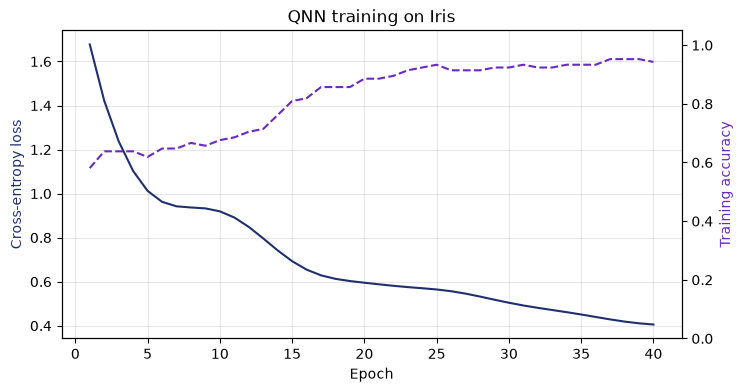

In [4]:
qnn = QuantumNeuralNetwork(n_qubits=4, n_layers=4, n_classes=N_CLASSES, seed=0)
history = qnn.train(X_train, y_train, epochs=40, learning_rate=0.1)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(range(1, len(history["loss"]) + 1), history["loss"], color="#20306f", label="Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss", color="#20306f")
ax2 = ax1.twinx()
ax2.plot(range(1, len(history["accuracy"]) + 1), history["accuracy"], color="#6929C4", linestyle="--", label="Accuracy")
ax2.set_ylabel("Training accuracy", color="#6929C4")
ax2.set_ylim(0, 1.05)
plt.title("QNN training on Iris")
ax1.grid(alpha=0.3)
plt.show()

### Evaluation

Finally, we classify the test flowers, which the network hasn't seen during training. The confusion matrix shows which species are mixed up: its rows are the true species, its columns the predicted ones. We also check how much probability the trained network still assigns to the unused outcome $c = 3$.

In [5]:
from sklearn.metrics import confusion_matrix

predictions = qnn.predict(X_test)
print(f"Test accuracy: {np.mean(predictions == y_test):.3f}\n")

matrix = confusion_matrix(y_test, predictions)
print(f"{'':>12}" + "".join(f"{name:>12}" for name in iris.target_names))
for name, row in zip(iris.target_names, matrix):
    print(f"{name:>12}" + "".join(f"{count:>12}" for count in row))

unused = np.mean([qnn.probabilities(x)[3] for x in X_test])
print(f"\nMean probability of the unused outcome 3: {unused:.3f}")

Test accuracy: 0.978

                  setosa  versicolor   virginica
      setosa          15           0           0
  versicolor           0          15           0
   virginica           0           1          14

Mean probability of the unused outcome 3: 0.035


## Summary

In this tutorial we

- encoded the four Iris features into four qubits with angle encoding,
- built a layered QNN of trainable $R_Y$ rotations and $CZ$ entanglers, compiled once with symbolic parameters,
- used a two-qubit `QuantumFloat` as readout register, whose outcomes directly represent the classes,
- trained the network with the cross-entropy loss, parameter-shift gradients and the Adam optimizer.

If you're curious, natural next steps could be to change the number of layers, to encode every feature several times between the trainable layers ([data re-uploading](https://quantum-journal.org/papers/q-2020-02-06-226/)), or to try a larger dataset such as MNIST, which requires reducing the images to a few features first.